# Practice Session 06: Network models


Author: <font color="blue">Javier Algarra Pérez</font>

E-mail: <font color="blue">jalgarra@estudiant.upf.edu</font>

Date: <font color="blue">7/11/2025</font>

# 1. Random (ER) graph generator

In [56]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import itertools

from collections import OrderedDict

The following function, which you can leave as-is, will be useful. It returns `True` with probability *p*, and `False` with probability *1-p*:

In [57]:
# Leave as-is

def flip_coin(p):
    if np.random.random() < p:
        return True
    else:
        return False

## 1.1. Generate ER graph

In [58]:
def generate_random_graph(N, p):
    G = nx.Graph()
    G.add_nodes_from(range(N))
    for u, v in itertools.combinations(G.nodes, 2):
        if flip_coin(p):
            G.add_edge(u, v)
    return G

In [59]:
# generate_random_graph function defined above
G = generate_random_graph(10, 0.3)
print(G.edges())

[(0, 5), (1, 2), (1, 4), (1, 9), (2, 5), (2, 8), (3, 7), (3, 9), (4, 5), (4, 6), (5, 8)]


In [60]:
#Replace this cell with your code to generate 1000 graphs and keep their number of edges in the array ``observed_edges``.
trials = 1000
N = 200
p = 0.05
observed_edges = []
for _ in range(trials):
    g = generate_random_graph(N, p)
    observed_edges.append(g.number_of_edges())
expected_edges = p * N * (N - 1) / 2

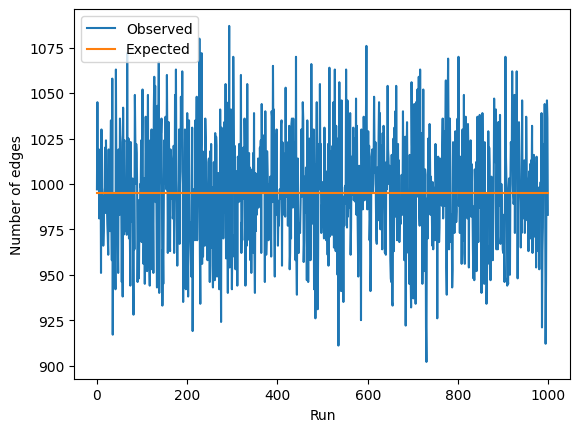

In [61]:
# Leave as-is

plt.xlabel("Run")
plt.ylabel("Number of edges")
plt.plot(range(trials), observed_edges, label="Observed")
plt.plot(range(trials), [expected_edges] * trials, label="Expected")
plt.legend()
plt.show()

In [62]:
def generate_random_graph_avg_degree(N, kavg):
    p = kavg / (N - 1)
    return generate_random_graph(N, p)

In [63]:
def graph_average_degree(g):
    num_nodes = g.number_of_nodes()
    return 2 * g.number_of_edges() / num_nodes

In [64]:
N = 500
target_average_degrees = np.round(np.arange(0.0, 3.1, 0.1), 2)
observed_average_degrees = []

for target_degree in target_average_degrees:
    g = generate_random_graph_avg_degree(N, target_degree)
    assert g.number_of_nodes() == N, "Wrong number of nodes"
    observed_degree = graph_average_degree(g)
    observed_average_degrees.append(observed_degree)

C:\Users\jalgarra\AppData\Local\Temp\ipykernel_11780\1970829798.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


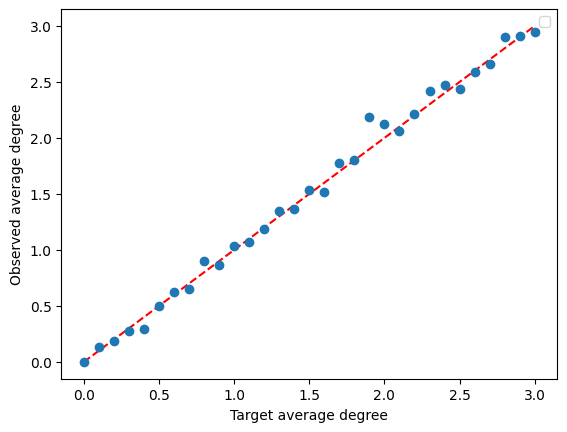

In [65]:
# Leave as-is

#!! Be careful make sure to run the previous cell just before running this one as we will be using some of the variables later and it can cause issues

plt.xlabel("Target average degree")
plt.ylabel("Observed average degree")
plt.scatter(target_average_degrees, observed_average_degrees)
plt.plot([0,max(target_average_degrees)], [0,max(target_average_degrees)], 'r--', zorder= 0)
plt.legend()
plt.show()

## 1.2. Measure connectivity


In [66]:
def is_connected(g):
    for u,v in itertools.combinations(g.nodes, 2): 
        if not nx.has_path(g, u, v): 
            return False 
    return True

The following code, which you should leave as-is, returns the size of the largest connected component on a graph.


In [67]:
# Leave as-is

def size_largest_cc(G):

    # Obtain the list of connected components of the graph sorted from largest to smallest
    Gcc = sorted(nx.connected_components(G), key=len, reverse=True)

    # Selects the first connected component in that list
    G0 = G.subgraph(Gcc[0])

    # Returns its number of nodes
    return G0.number_of_nodes()

In [68]:
N = 1000
target_average_degrees = np.arange(0.2, 2.0, 0.05)

largest_cc_sizes = []
average_degrees = []

for target_average_degree in target_average_degrees:
    
    g = generate_random_graph_avg_degree(N, target_average_degree)
    assert g.number_of_nodes() == N, "Wrong number of nodes"
    
    average_degree = graph_average_degree(g)
    average_degrees.append(average_degree)
    
    largest_cc_size = size_largest_cc(g)/N
    largest_cc_sizes.append(largest_cc_size)

The following code shows this visually.


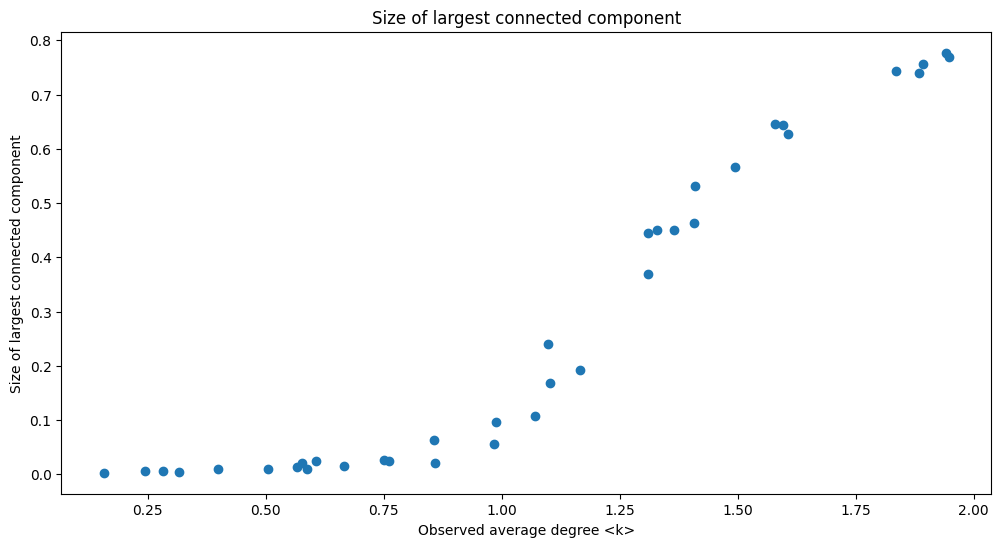

In [69]:
# LEAVE AS-IS

plt.figure(figsize=(12,6))
plt.scatter(average_degrees, largest_cc_sizes)
plt.title("Size of largest connected component")
plt.xlabel("Observed average degree <k>")
plt.ylabel("Size of largest connected component")
plt.show()

Como se observa en el gráfico, los valores permanecen prácticamente constantes durante la mayor parte del rango: el tamaño de la componente conexa más grande no varía significativamente. Sin embargo, al aproximarnos a 𝑘≈1 comienza a producirse un aumento notable. Por lo tanto, nuestros resultados son coherentes.

## 1.3. Degree distributions and Cumulative Degree Distributions

In [70]:
def print_er_statistics(graph, p):
    avg_degree_obs = graph_average_degree(graph)
    n_nodes = graph.number_of_nodes()
    avg_degree_exp = p * (n_nodes - 1)

    print(f"Graph with N={n_nodes}, p={p}")
    print(f"Observed average degree <k>: {avg_degree_obs:.4f}")
    print(f"Expected theoretical <k>: {avg_degree_exp:.4f}")
    print()


In [71]:
N = 500
p_values = [0.01, 0.03, 0.1]
for p in p_values:
    g = generate_random_graph(N, p)
    print_er_statistics(g, p)

Graph with N=500, p=0.01
Observed average degree <k>: 4.8760
Expected theoretical <k>: 4.9900

Graph with N=500, p=0.03
Observed average degree <k>: 15.2560
Expected theoretical <k>: 14.9700

Graph with N=500, p=0.1
Observed average degree <k>: 49.5360
Expected theoretical <k>: 49.9000



You can use the following function (as-is, or modified) to plot the degree distribution in a graph.

In [72]:
# Leave as-is or modify if you want
def plot_degree_distributions(g_list, p_values):
    plt.figure(figsize=(12, 6))

    for g, p in zip(g_list, p_values):
        degree_dict = dict(g.degree())
        degree_sequence = list(degree_dict.values())

        prob, bin_edges = np.histogram(
            degree_sequence,
            bins=range(1, np.max(degree_sequence) + 2),
            density=True
        )

        plt.plot(bin_edges[:-1], prob, 'o-', label=f'p={p}')

    plt.title("Probability Density Function (Degree Distribution)")
    plt.xlabel("Degree")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


def plot_cumulative_degree_distributions(g_list, p_values):
    plt.figure(figsize=(12, 6))

    for g, p in zip(g_list, p_values):
        degree_dict = dict(g.degree())
        degree_sequence = list(degree_dict.values())

        degree_counts, bin_edges = np.histogram(
            degree_sequence,
            bins=range(1, np.max(degree_sequence) + 2),
            density=True
        )

        cumulative_distribution = np.cumsum(degree_counts[::-1])[::-1]

        plt.plot(bin_edges[:-1], cumulative_distribution, 'o-', label=f'p={p}')

    plt.title("Cumulative Degree Distribution (P(k' ≥ k))")
    plt.xlabel("Degree (k)")
    plt.ylabel("Cumulative Probability")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


Graph with N=>2500, p=>0.001, edges=>3138
Graph with N=>2500, p=>0.01, edges=>31270
Graph with N=>2500, p=>0.1, edges=>311599
Graph with N=>2500, p=>0.5, edges=>1561809
Graph with N=>2500, p=>0.9, edges=>2812560


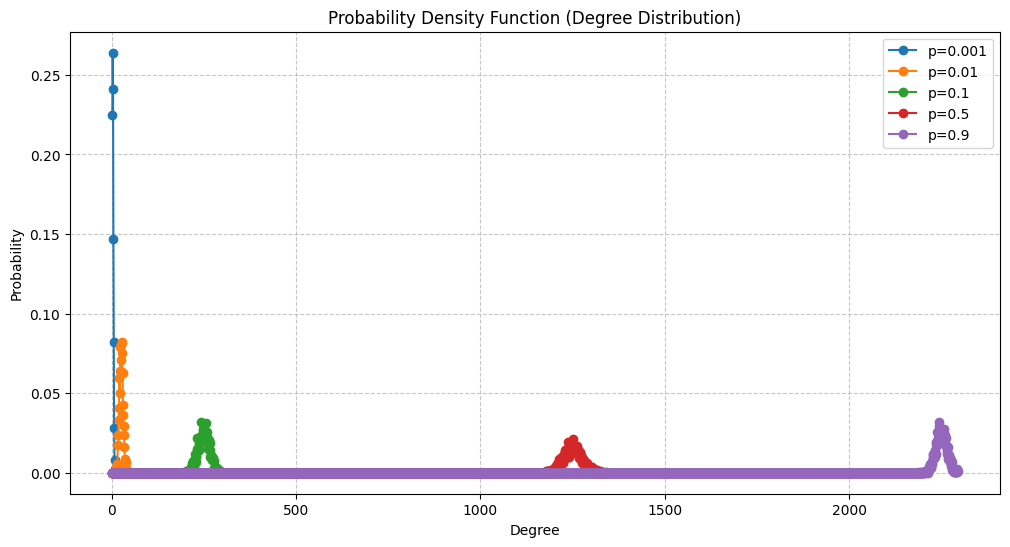

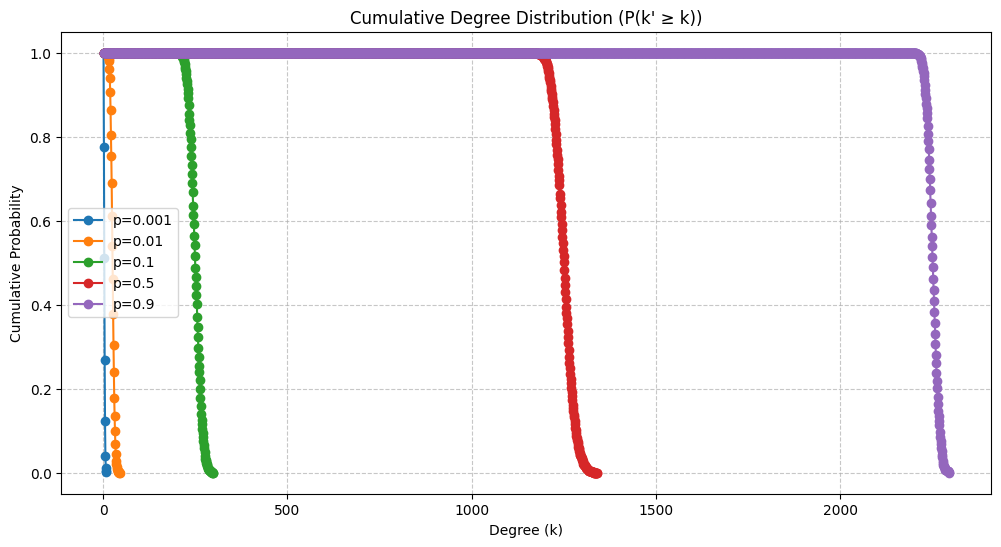

In [73]:
N = 2500
p_values = [0.001, 0.01, 0.1, 0.5, 0.9]
g_list = []
for p in p_values:
    g = generate_random_graph(N, p)
    g_list.append(g)
    print(f"Graph with N=>{N}, p=>{p}, edges=>{g.number_of_edges()}")
plot_degree_distributions(g_list, p_values)
plot_cumulative_degree_distributions(g_list, p_values)

# 2. Preferential attachment (BA) generator

In [74]:
# LEAVE AS-IS

def select_with_probability(x, m, p):
    return np.random.choice(x, size=m, replace=False, p=p)

The next cell, which you should leave as-is, tests this function.

In [75]:
# LEAVE AS-IS

trials = 1500
vector = ['a', 'b', 'c']
probabilities = [0.75, 0.13, 0.12]

all_selected = []
for i in range(trials):
    selected = select_with_probability(vector, 1, probabilities)[0]
    all_selected.append(selected)

for i, p in zip(vector, probabilities):
    print("Element {:s} was selected {:d} times, expected {:.0f}".format(i, all_selected.count(i), trials*p) )

Element a was selected 1119 times, expected 1125
Element b was selected 194 times, expected 195
Element c was selected 187 times, expected 180


In [76]:
def select_targets(g, m):

    # Check if feasible
    N = g.number_of_nodes()  
    if N < m:
        raise ValueError('Graph has less than m nodes')

    # Compute sum of degree
    sum_degree = 0
    for (node, degree) in g.degree():
        sum_degree += degree

    # YOUR CODE HERE: COMPUTE SUM OF DEGREE OF NODES
    if sum_degree == 0:
        raise ValueError('Graph as no edges')

    # Compute probabilities
    probabilities = []
    for (node, degree) in g.degree():
        # YOUR CODE HERE: COMPUTE PROBABILITY OF SELECTING NODE u
        # THEN APPEND IT TO probabilities USING probabilities.append(...)
        probability = degree / sum_degree
        probabilities.append(probability)

    # Sample m nodes according to probabilities without replacement
    selected = select_with_probability(list(g.nodes()), m, probabilities)

    return selected

In [77]:
def generate_preferential_attachment_graph(N, m0, m):
    g = nx.Graph()
    g.add_nodes_from(range(m0))

    for i in range(m0):
        g.add_edge(i, (i + 1) % m0)

    for u in range(m0, N):
        targets = select_targets(g, m)
        g.add_node(u)
        for t in targets:
            g.add_edge(u, t)

    return g


In [78]:
# Leave as is
def estimate_alpha_mle(degrees, k_min=1):
    degrees = np.array(degrees)
    degrees = degrees[degrees >= k_min]
    n = len(degrees)
    alpha = 1 + n / np.sum(np.log(degrees / (k_min - 0.5)))
    return alpha

In [79]:
def plot_degree_distribution_loglog(g, k_min=1):
    degree_dict = dict(g.degree())
    degree_sequence = np.array(list(degree_dict.values()))
    degree_sequence = degree_sequence[degree_sequence >= k_min]
    
    # Compute empirical histogram
    prob, bin_edges = np.histogram(
        degree_sequence,
        bins=range(k_min, np.max(degree_sequence)+2),
        density=True
    )
    
    x = bin_edges[:-1]
    y = prob
    
    # Remove zeros (log scale)
    mask = y > 0
    x = x[mask]
    y = y[mask]
    
    # Estimate alpha using MLE
    # ONE LINE TO FILL:
    alpha = estimate_alpha_mle(degree_sequence, k_min)
    
    # Compute fitted power-law line
    # Normalize to match the first bin of the empirical data
    y_fit = y[0] * (x / x[0]) ** (-alpha)
    
    # Plot
    plt.figure(figsize=(12,6))
    plt.loglog(x, y, 'o', alpha=0.7, label='Empirical data')
    plt.loglog(x, y_fit, '--', color='red', label=f'MLE Power-law fit: α={alpha:.2f}')
    
    plt.xlabel("Degree (k)")
    plt.ylabel("P(k)")
    plt.title("Degree Distribution (Log-Log Scale)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

Graph 1 → N=5000, m0=3, m=3
  Total nodes: 5000
  Total edges: 14994
  Mean degree: 6.00


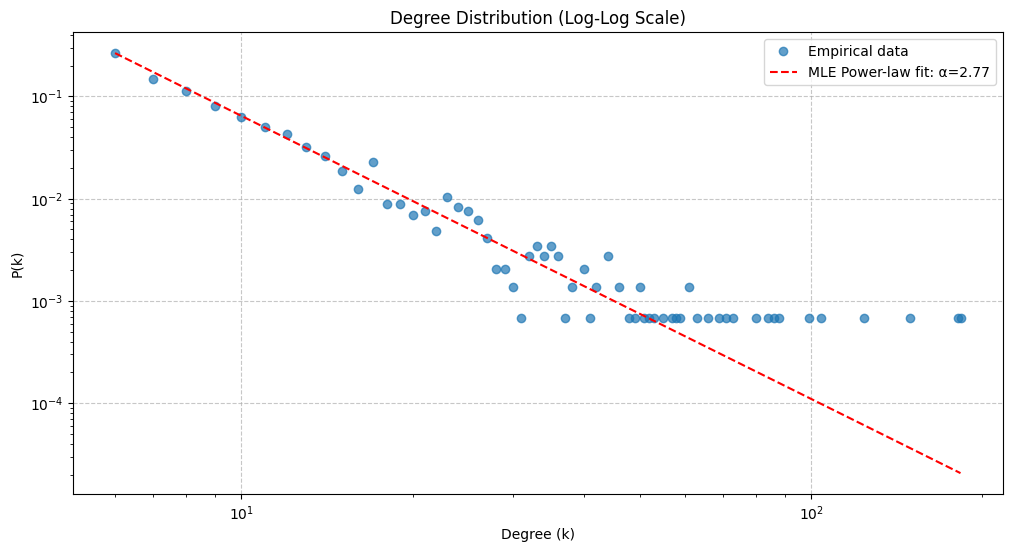


Graph 2 → N=5000, m0=5, m=5
  Total nodes: 5000
  Total edges: 24980
  Mean degree: 9.99


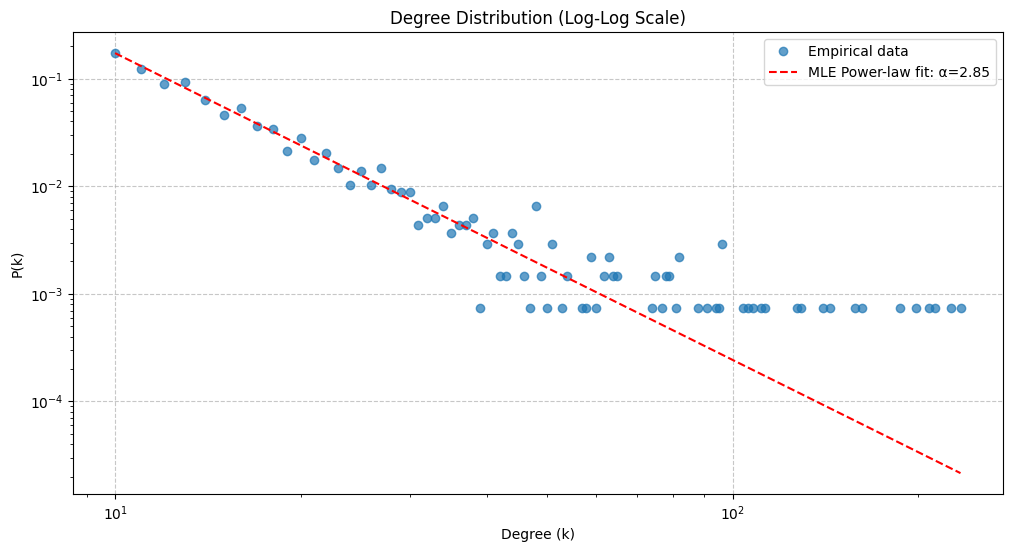

In [80]:
print("Graph 1 → N=5000, m0=3, m=3")
g_ba1 = generate_preferential_attachment_graph(5000, 3, 3)
print(f"  Total nodes: {g_ba1.number_of_nodes()}")
print(f"  Total edges: {g_ba1.number_of_edges()}")
print(f"  Mean degree: {graph_average_degree(g_ba1):.2f}")
plot_degree_distribution_loglog(g_ba1, k_min=2*3)

print("\nGraph 2 → N=5000, m0=5, m=5")
g_ba2 = generate_preferential_attachment_graph(5000, 5, 5)
print(f"  Total nodes: {g_ba2.number_of_nodes()}")
print(f"  Total edges: {g_ba2.number_of_edges()}")
print(f"  Mean degree: {graph_average_degree(g_ba2):.2f}")
plot_degree_distribution_loglog(g_ba2, k_min=2*5)


En una red BA, el valor teórico del exponente es α=3. Como podemos observar, los valores obtenidos presentan muy poca variación, ya que el sistema está muy próximo a ese valor teórico. Solo se alcanza exactamente en el límite cuando el tamaño de la red tiende a infinito. Son valores que se aproximan progresivamente.

# 3. ER and BA graph Comparison

In [81]:
#Leave as is
def plot_degree_distribution(g):
    degree_dict = dict(g.degree())
    degree_ordered = OrderedDict(sorted(degree_dict.items(), key=lambda x: x[1], reverse=True))
    degree_sequence = list(degree_ordered.values())
    prob, bin_edges = np.histogram(degree_sequence, bins=range(1,np.max(degree_sequence)+2), density=True)
    plt.figure(figsize=(12,6))
    plt.loglog(bin_edges[:-1], prob, 'o-')
    plt.title("Probability density function")
    plt.xlabel("degree")
    plt.ylabel("probability")
    plt.autoscale(enable=True, axis='both')
    plt.show()

ER graph → N=300, edges=910, avg. degree=6.07
BA graph → N=300, edges=300, avg. degree=2.00


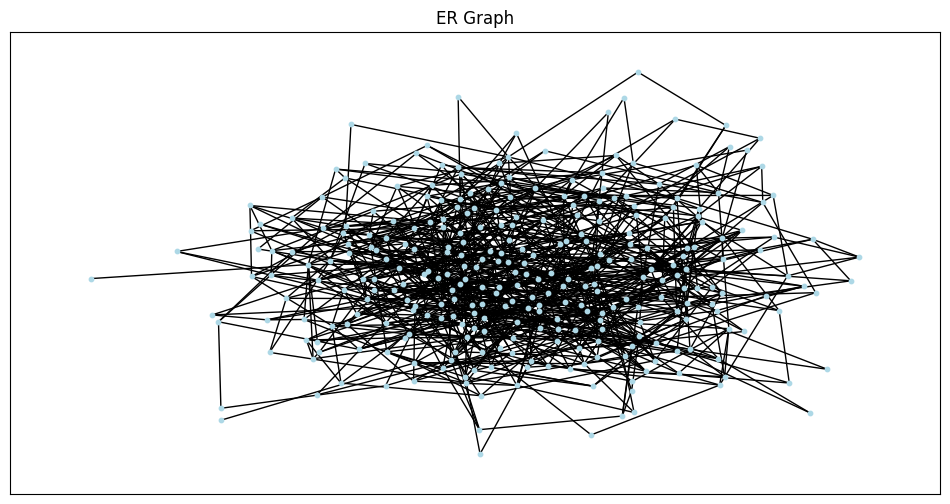

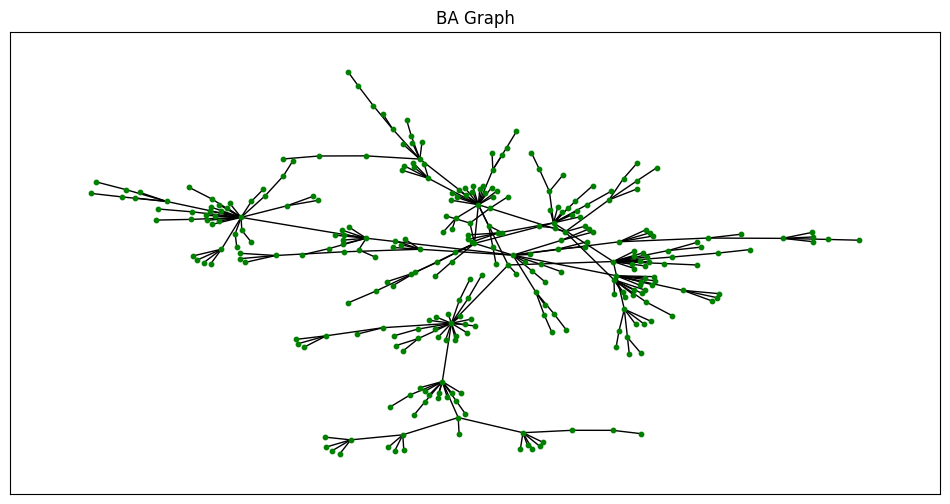


ER Graph Degree Distribution:


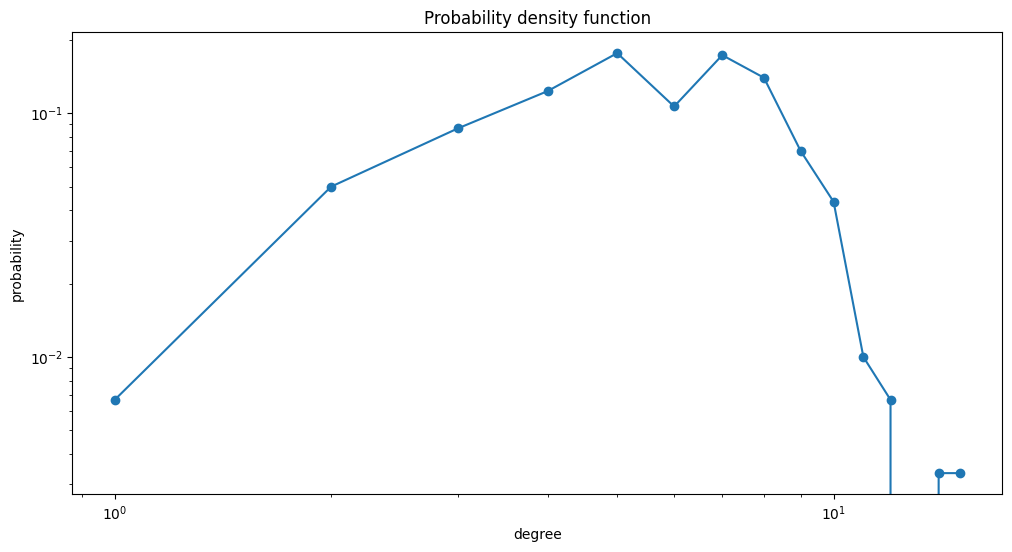


BA Graph Degree Distribution:


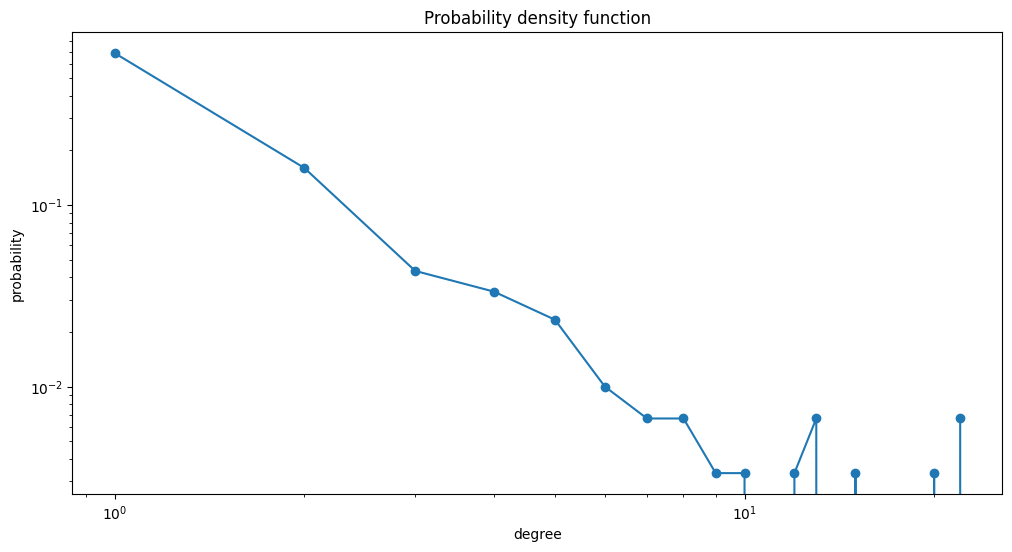

In [82]:
N = 300
p = 0.02
g_er = generate_random_graph(N, p)
m0 = 5
m = 1


g_ba = generate_preferential_attachment_graph(N, m0, m)

print(f"ER graph → N={g_er.number_of_nodes()}, edges={g_er.number_of_edges()}, avg. degree={graph_average_degree(g_er):.2f}")
print(f"BA graph → N={g_ba.number_of_nodes()}, edges={g_ba.number_of_edges()}, avg. degree={graph_average_degree(g_ba):.2f}")

plt.figure(figsize=(12, 6))
pos_er = nx.spring_layout(g_er)
nx.draw_networkx(g_er, pos_er, with_labels=False, node_size=10, node_color='lightblue')
plt.title(f"ER Graph")
plt.show()
plt.figure(figsize=(12, 6))
pos_ba = nx.spring_layout(g_ba)
nx.draw_networkx(g_ba, pos_ba, with_labels=False, node_size=10, node_color='green')
plt.title(f"BA Graph")
plt.show()
print()
print("ER Graph Degree Distribution:")
plot_degree_distribution(g_er)
print()
print("BA Graph Degree Distribution:")
plot_degree_distribution(g_ba)

El grafo ER es bastante uniforme: los nodos suelen tener grados parecidos y la distribución se concentra alrededor del valor medio. En cambio, en el grafo BA aparecen hubs. La mayoría de los nodos tienen grados pequeños y se conectan sobre todo a estos hubs. En la distribución de grados se ve claramente: lo más común es que un nodo tenga un grado cercano a 1, y la probabilidad va bajando a medida que aumenta el grado.

<font size="+2" color="#003300">I hereby declare that, except for the code provided by the course instructors, all of my code, report, and figures were produced by myself.</font>